In [1]:
# Basic libraries for data handling and plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Scikit-learn tools
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Load the built-in diabetes dataset from sklearn
diabetes = load_diabetes()

In [3]:
# Convert the feature matrix into a DataFrame
# diabetes.data contains the row values
# diabetes.feature_names contains the column names
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

# Add the target column separately
df["target"] = diabetes.target

In [4]:
# Shape of the dataset
print("Shape of feature data:", diabetes.data.shape)
print("Shape of target data:", diabetes.target.shape)

# First few rows
df.head()

Shape of feature data: (442, 10)
Shape of target data: (442,)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [5]:
# These are the input columns in the dataset
print("Feature names:")
print(diabetes.feature_names)

# Optional: dataset description
# print(diabetes.DESCR)

Feature names:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [6]:
# We are using only one feature: bmi
# Double brackets make it a DataFrame, not a Series
X = df[["bmi"]]

# Target variable: what we want to predict
y = df["target"]

In [7]:
# Split the dataset into training and testing sets
# train set -> used to teach the model
# test set -> used to check how well the model performs on unseen data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Check shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (353, 1)
X_test shape: (89, 1)
y_train shape: (353,)
y_test shape: (89,)


In [8]:
# Create the model object
model = LinearRegression()

In [9]:
# Fit the model using training data
# X_train = input feature values
# y_train = actual target values for training
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
# Slope of the regression line
print("Coefficient (slope):", model.coef_)

# Intercept of the regression line
print("Intercept:", model.intercept_)

Coefficient (slope): [998.57768914]
Intercept: 152.00335421448167


In [11]:
# Predict target values for test feature values
y_pred = model.predict(X_test)

# Show first few predictions
print("First 10 predicted values:")
print(y_pred[:10])

print("\nFirst 10 actual values:")
print(y_test.values[:10])

First 10 predicted values:
[145.80622687 188.85739048 147.95878505 203.92529774 131.8145987
 127.50948234 322.31599764 197.4676232   61.85645785 167.33180868]

First 10 actual values:
[219.  70. 202. 230. 111.  84. 242. 272.  94.  96.]


In [12]:
# Calculate error and accuracy metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

Mean Absolute Error: 52.25997644534553
Mean Squared Error: 4061.8259284949268
Root Mean Squared Error: 63.73245584860925
R2 Score: 0.23335039815872138


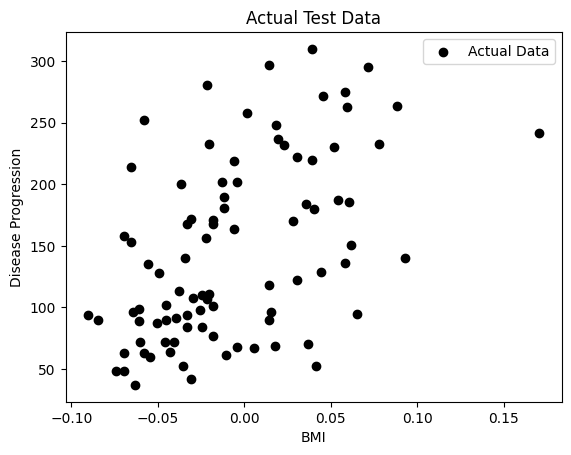

In [13]:
# Scatter plot of actual test values
plt.scatter(X_test, y_test, color="black", label="Actual Data")
plt.xlabel("BMI")
plt.ylabel("Disease Progression")
plt.title("Actual Test Data")
plt.legend()
plt.show()

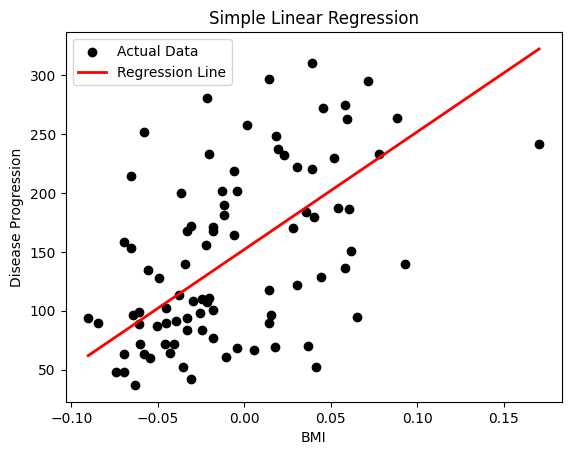

In [14]:
# Predict values for test input
y_line = model.predict(X_test)

# Sort X values so the line looks proper
sorted_idx = X_test["bmi"].argsort()

# Plot actual test points
plt.scatter(X_test, y_test, color="black", label="Actual Data")

# Plot regression line
plt.plot(
    X_test["bmi"].iloc[sorted_idx],
    y_line[sorted_idx],
    color="red",
    linewidth=2,
    label="Regression Line"
)

plt.xlabel("BMI")
plt.ylabel("Disease Progression")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()

In [15]:
# Example: predict disease progression for a new BMI value
# Must be 2D input, so use double brackets
new_bmi = pd.DataFrame([[0.05]], columns=["bmi"])

predicted_score = model.predict(new_bmi)
print("Predicted disease progression:", predicted_score[0])

Predicted disease progression: 201.93223867135964
